## Regression-Based Harmonisation

As a simple baseline, we can use regression to remove site-related mean shifts from the data.

For each feature, we fit a model like:

$$
y = \beta_0 + \beta_1 \text{Age} + \beta_2 \text{Timepoint} + \gamma \text{Site} + \epsilon
$$

Here:

- the **site term** captures additive scanner/batch effects,
- age and timepoint are kept as biological covariates,
- the residual part represents variation not explained by site.

This is useful as a first step, but it only handles **additive** site effects.  
If sites also differ in **variance** or spread, regression alone will not fully correct the problem.

That is one reason ComBat-like methods are needed: they aim to correct both mean shifts and variance differences while preserving biological signal.

# Regression-Based Harmonisation Workflow

In this section, we will use a simple regression-based approach to reduce site-related variability in the simulated data.

The goal is to demonstrate:
- what regression-based harmonisation can correct,
- and why more advanced methods such as ComBat-like approaches may still be needed.

---

## Steps

### 1. Simulate longitudinal multi-site data

We first generate synthetic imaging data containing:

- repeated measurements,
- biological variation,
- covariate effects (e.g., Age),
- additive site effects,
- and multiplicative site effects.

This creates a realistic harmonisation scenario where scanner/site effects are intentionally introduced.

---

### 2. Visualize site-related effects

Before harmonisation, we inspect the distributions across sites using boxplots.

This helps identify:
- additive effects → shifts in mean values,
- multiplicative effects → differences in spread/variance.

---

### 3. Apply regression-based harmonisation

We fit regression models that include:
- biological covariates,
- timepoint information,
- and site/scanner terms.

The estimated site effects are then removed from the data.

This approach primarily targets additive batch effects.

---

### 4. Visualize the harmonized data

We compare the distributions before and after correction to assess:
- reduction in site-related mean shifts,
- preservation of biological variability,
- and any remaining variance differences.

---

### 5. Evaluate remaining batch effects

Finally, we re-run:
- additive effect tests,
- multiplicative effect tests,
- and reliability metrics.

This allows us to evaluate how much scanner/site variability remains after harmonisation.

---

## Key Concept

Regression-based harmonisation is useful for correcting systematic mean shifts across sites.

However, if scanners also differ in variability or scale, regression alone may not be sufficient.

This motivates the use of ComBat-like harmonisation methods, which aim to model and remove both:
- additive effects,
- and multiplicative effects.

   Subject Timepoint    Site   Age  Region_1  Region_2  Region_3  Region_4
0        1       TP0  Site_B  78.0    2380.5     311.5    2362.7    2381.3
1        1       TP1  Site_A  78.0    1553.1    1432.5    2487.1    2139.8
2        1       TP2  Site_A  78.0    1533.2    1459.7    2497.8    2631.7
3        2       TP0  Site_A  60.1    1660.3    1607.4    2150.7    2665.7
4        2       TP1  Site_B  60.1    2484.2    2538.6    1978.2    2424.2
5        2       TP2  Site_A  60.1    1700.5    1658.8    2159.9    2834.3
6        3       TP0  Site_A  60.8    1634.4    1476.3    2191.8    2028.4
7        3       TP1  Site_A  60.8    1626.8    1512.9    2169.2    2479.2
8        3       TP2  Site_A  60.8    1634.4    1512.3    2220.3    2382.6
9        4       TP0  Site_A  56.4    1629.5    1742.7    2199.9    2286.1


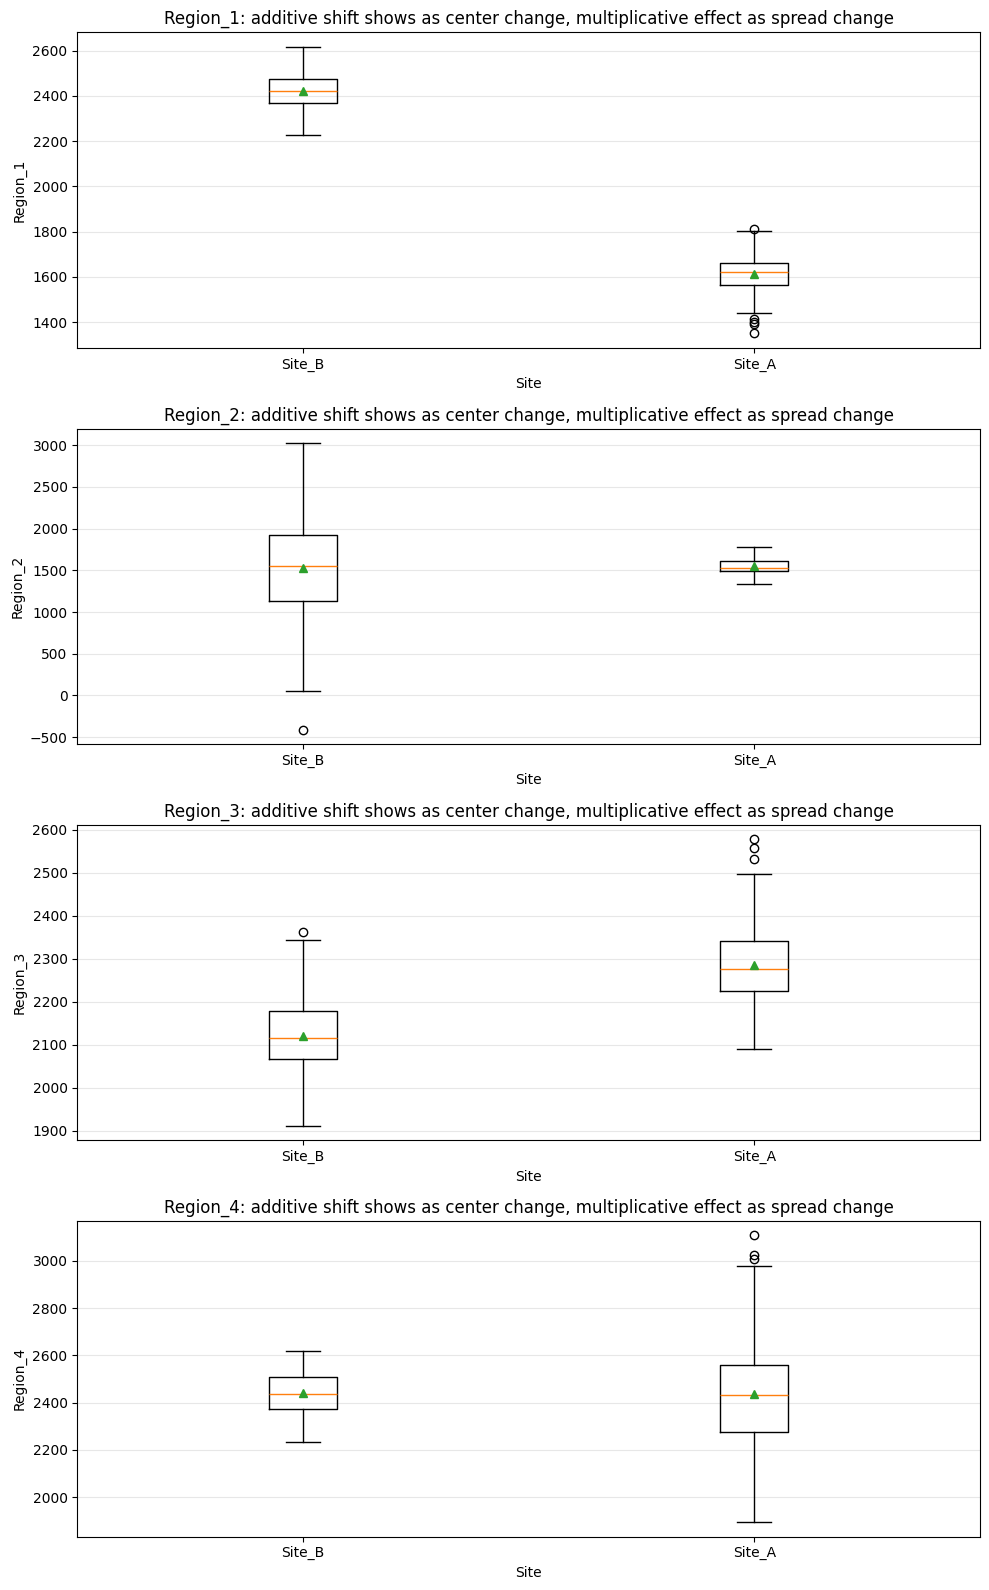

In [6]:
import importlib
import HarmonisationEvaluation_functions
import HarmonisationEvaluation_plots

importlib.reload(HarmonisationEvaluation_functions)
importlib.reload(HarmonisationEvaluation_plots)

from HarmonisationEvaluation_functions import simulate_longitudinal_batch_data_mixed
from HarmonisationEvaluation_plots import plot_additive_multiplicative_effects


additive_shift = {
    "Site_B": {"Region_1": 800, "Region_3": -150}
}

multiplicative_scale = {
    "Site_B": {"Region_2":30.0},
    "Site_A": {"Region_4": 10}
}

df = simulate_longitudinal_batch_data_mixed(
    n_subjects=100,
    n_timepoints=3,
    n_sites=2,
    n_features=4,
    additive_shift=additive_shift,
    multiplicative_scale=multiplicative_scale,
    seed=1
)

print(df.head(10))
feature_cols = ["Region_1", "Region_2", "Region_3", "Region_4"]
plot_additive_multiplicative_effects(df, feature_cols=feature_cols, batch_col="Site")


    Feature                                  Formula    Site_pvalue        R2
0  Region_1  Region_1 ~ Age + C(Timepoint) + C(Site)  1.632206e-212  0.962826
1  Region_2  Region_2 ~ Age + C(Timepoint) + C(Site)   7.166434e-01  0.027210
2  Region_3  Region_3 ~ Age + C(Timepoint) + C(Site)   6.696867e-42  0.477192
3  Region_4  Region_4 ~ Age + C(Timepoint) + C(Site)   7.744116e-01  0.012216
   Subject Timepoint    Site   Age  Region_1  Region_2  Region_3  Region_4  \
0        1       TP0  Site_B  78.0    2380.5     311.5    2362.7    2381.3   
1        1       TP1  Site_A  78.0    1553.1    1432.5    2487.1    2139.8   
2        1       TP2  Site_A  78.0    1533.2    1459.7    2497.8    2631.7   
3        2       TP0  Site_A  60.1    1660.3    1607.4    2150.7    2665.7   
4        2       TP1  Site_B  60.1    2484.2    2538.6    1978.2    2424.2   

   Region_1_harm  Region_2_harm  Region_3_harm  Region_4_harm  
0    1897.147971     322.295887    2461.000645    2377.844763  
1    1903.689

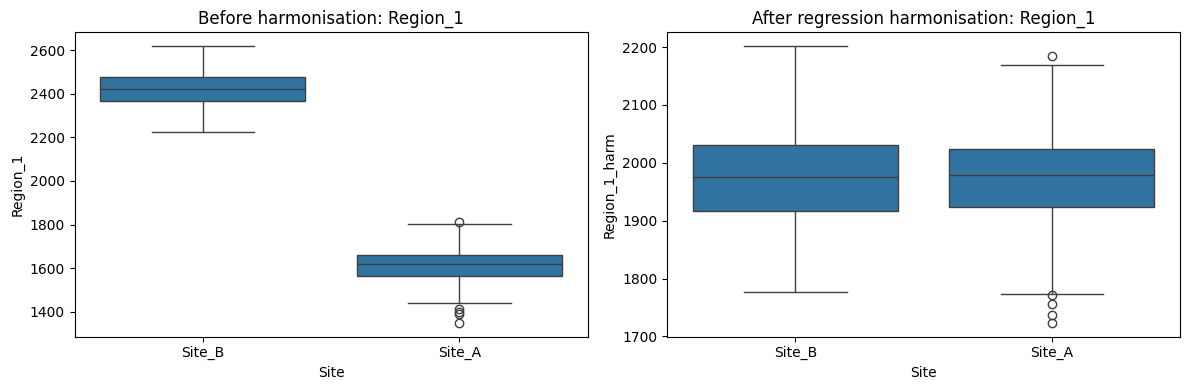

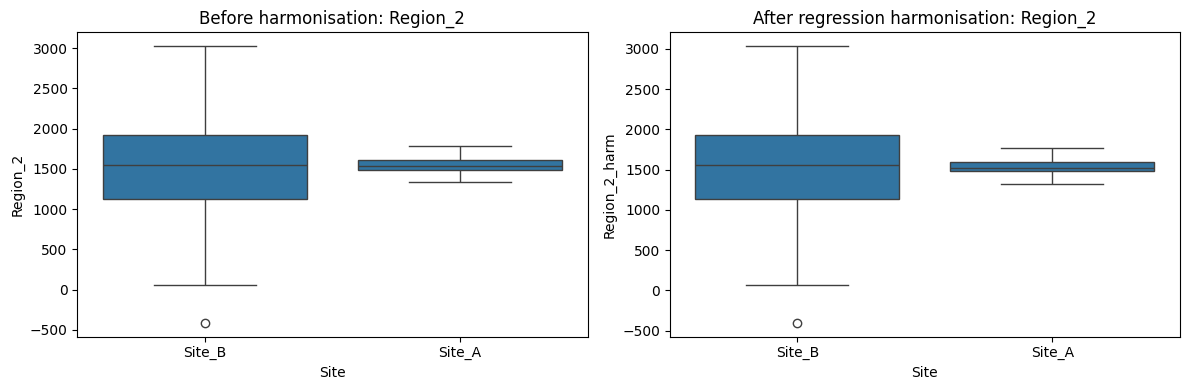

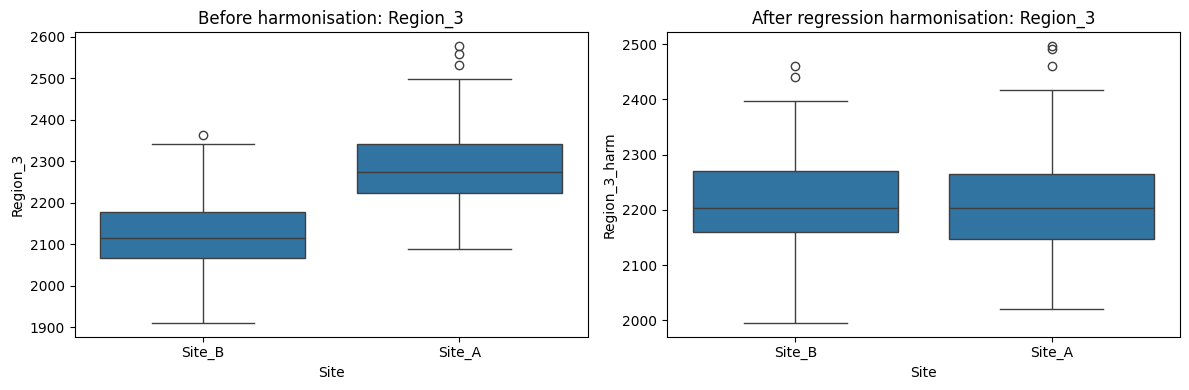

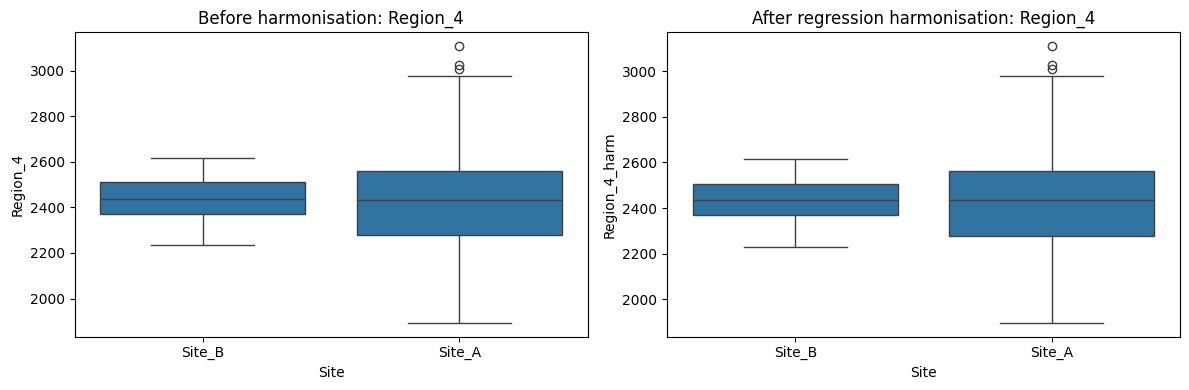

In [10]:
import importlib
import HarmonisationEvaluation_functions
import HarmonisationEvaluation_plots


importlib.reload(HarmonisationEvaluation_functions)
importlib.reload(HarmonisationEvaluation_plots)


from HarmonisationEvaluation_functions import regression_harmonize_site
from HarmonisationEvaluation_plots import plot_before_after_by_site


feature_cols = ["Region_1", "Region_2", "Region_3", "Region_4"]

df_harm, model_summary = regression_harmonize_site(
    df,
    feature_cols=feature_cols,
    site_col="Site",
    covariates=("Age", "Timepoint")
)

print(model_summary)
print(df_harm.head())

plot_before_after_by_site(df_harm, feature_cols)

## Interpreting the Regression Output

The regression summary table provides feature-wise information about the relationship between the imaging measurements and site effects.

Typical columns include:

- **Feature**  
  The imaging feature/region being analysed.

- **Formula**  
  The regression model used for harmonisation.

- **Site_pvalue**  
  Statistical significance of the site/scanner term.

  - small p-values suggest strong site-related mean shifts
  - non-significant values suggest weaker additive batch effects

- **R2**  
  Proportion of variance explained by the regression model.

Higher values indicate that the model explains a larger portion of variability in the feature.

---

### Expected observations

Before harmonisation:
- regions with simulated additive effects should often show significant site terms.

After regression-based harmonisation:
- site-related mean differences should reduce,
- and visual separation across sites should become smaller.

However, variance differences may still remain for regions with multiplicative batch effects.

## Exercise: Regression-Based Harmonisation

In this exercise, simulate longitudinal multi-site imaging data containing:

- additive batch effects,
- multiplicative batch effects,
- and biological covariates (e.g., Age).

Then:

1. Visualize the site-related effects before harmonisation.
2. Apply regression-based harmonisation.
3. Visualize the harmonized data.
4. Re-run additive and multiplicative effect tests.

### Questions

- Which site effects were reduced after regression harmonisation?
- Which effects still remained?
- Why might regression be insufficient for multiplicative batch effects?
- How could ComBat-like methods improve upon this?